# Deep Learning: Flower Classification 

The following notebook was created for a Kaggle competition. The dataset is available on [Kaggle](https://www.kaggle.com/competitions/tpu-getting-started/data), and one of the objectives of the competition is to train a deep learning model using Tensor Processing Units (TPUs) (or alternatively GPUs).

The challenge is to build a machine learning model that can identify the type of flower in a dataset of images. The goal is to classify images into **104 classes** (flower species).

In [11]:
# Import Python packages 
import math, re, os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

## Create Distribution Strategy

In [12]:
# Detect TPU, return appropriate distribution strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)   # non-experimental
else:
    strategy = tf.distribute.get_strategy()     # default: usa 1 sola GPU (o CPU)

print("REPLICAS: ", strategy.num_replicas_in_sync)

REPLICAS:  1


## Upload data

Each file contains the "id", "label" (the class of the sample, for training data) and "img" (the actual pixels in array form) information for many images. 

In [13]:
#Upload data (data are already  pre-split)
# Pictures are in format 192x192, 224x224, 331x331, 512x512
FLW_DS_PATH = '/kaggle/input/competitions/tpu-getting-started'
IMAGE_SIZE = [331, 331]
RES = '331x331'   
FLW_PATH = FLW_DS_PATH + '/tfrecords-jpeg-{RES}'
AUTO = tf.data.AUTOTUNE

# .tfrec for TFRecord box
train_files = tf.io.gfile.glob(f'{FLW_DS_PATH}/tfrecords-jpeg-{RES}/train/*.tfrec')
val_files   = tf.io.gfile.glob(f'{FLW_DS_PATH}/tfrecords-jpeg-{RES}/val/*.tfrec')
test_files  = tf.io.gfile.glob(f'{FLW_DS_PATH}/tfrecords-jpeg-{RES}/test/*.tfrec')
print(len(train_files), len(val_files), len(test_files))

16 16 16


## Data pipeline and exploration

Info about the classes of flowers: We have 104 classes with labels from 0 to 103.

In [14]:
# Info about the classes of flowers
def read_label_only(example):
    f = tf.io.parse_single_example(example, {"class": tf.io.FixedLenFeature([], tf.int64)})
    return f["class"]

labels = np.array(list(
    tf.data.TFRecordDataset(train_files).map(read_label_only).as_numpy_iterator()
))
num_classes = len(np.unique(labels))
print(num_classes, labels.min(), labels.max())   # 104, 0, 103

104 0 103


In [15]:
BATCH_SIZE = 16 * strategy.num_replicas_in_sync
EPOCHS = 12

# JPG into RGB
def decode_image(image_data):
    image = tf.image.decode_jpeg(image_data, channels=3)
    image = tf.cast(image, tf.float32) / 255.0 #pixel from 0-255 to 0-1
    return tf.reshape(image, [*IMAGE_SIZE, 3])

def read_labeled_tfrecord(example):
    fmt = {"image": tf.io.FixedLenFeature([], tf.string),
           "class": tf.io.FixedLenFeature([], tf.int64)}
    example = tf.io.parse_single_example(example, fmt)
    return decode_image(example['image']), tf.cast(example['class'], tf.int32)

def read_unlabeled_tfrecord(example):
    fmt = {"image": tf.io.FixedLenFeature([], tf.string),
           "id": tf.io.FixedLenFeature([], tf.string)}
    example = tf.io.parse_single_example(example, fmt)
    return decode_image(example['image']), example['id']

# Load and applying parsing
def load_dataset(filenames, labeled=True, ordered=False):
    opts = tf.data.Options()
    if not ordered:
        opts.deterministic = False
    ds = tf.data.TFRecordDataset(filenames, num_parallel_reads=AUTO).with_options(opts)
    return ds.map(read_labeled_tfrecord if labeled else read_unlabeled_tfrecord,
                  num_parallel_calls=AUTO)

def get_training_dataset():
    ds = load_dataset(train_files, labeled=True)
    return ds.repeat().shuffle(2048).batch(BATCH_SIZE).prefetch(AUTO)

def get_validation_dataset(ordered=False):
    ds = load_dataset(val_files, labeled=True, ordered=ordered)
    return ds.batch(BATCH_SIZE).cache().prefetch(AUTO)

def get_test_dataset(ordered=False):
    ds = load_dataset(test_files, labeled=False, ordered=ordered)
    return ds.batch(BATCH_SIZE).prefetch(AUTO)

# Count images
def count_data_items(filenames):
    return sum(int(re.search(r"-(\d+)\.tfrec$", f).group(1)) for f in filenames)

#Final train, validation and test sets
ds_train, ds_valid, ds_test = get_training_dataset(), get_validation_dataset(), get_test_dataset()

NUM_TRAINING_IMAGES = count_data_items(train_files)
NUM_TEST_IMAGES = count_data_items(test_files)
NUM_VALIDATION_IMAGES = count_data_items(val_files)
STEPS_PER_EPOCH = NUM_TRAINING_IMAGES // BATCH_SIZE

print(NUM_TRAINING_IMAGES)
print(NUM_TEST_IMAGES)
print(BATCH_SIZE)
print(STEPS_PER_EPOCH)

12753
7382
16
797


In [16]:
for imgs, labels in ds_train.take(1):
    print(imgs.shape, imgs.dtype)
    print(labels[:10].numpy())

print(ds_train.element_spec)

(16, 331, 331, 3) <dtype: 'float32'>
[ 4  0  8 67  9 16 76 14 52 60]
(TensorSpec(shape=(None, 331, 331, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


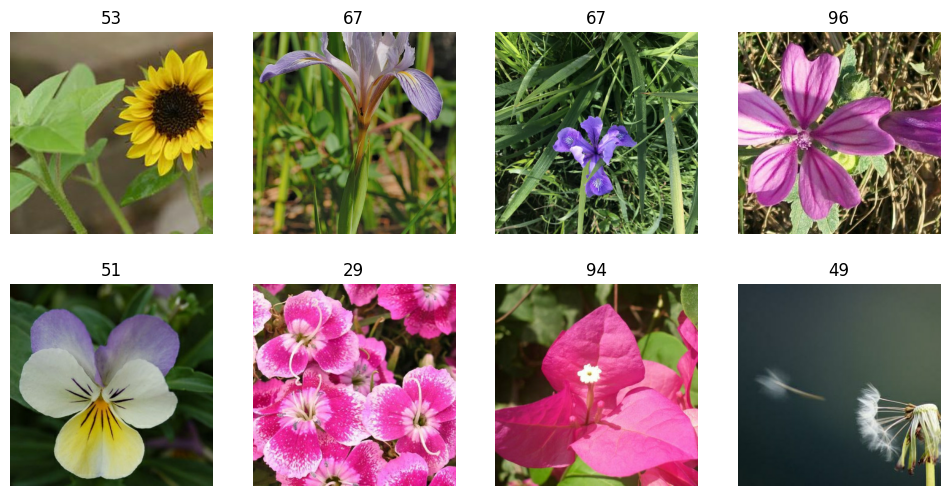

In [17]:
# Plot some images
for imgs, labels in ds_train.take(1): #a element of ds_train is a batch
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(imgs[i])
        plt.title(int(labels[i]))  
        plt.axis('off')
    plt.show()

## Define the model

In [18]:
with strategy.scope():
    # Define Pretrained Base
    pretrained_model = tf.keras.applications.VGG16(
        weights='imagenet',
        include_top=False ,
        input_shape=[*IMAGE_SIZE, 3]
    ) #DenseNet should work better than VGG16 on ImageNet but less fast
    pretrained_model.trainable = False

    # We add preprocessing to the model

    data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    #tf.keras.layers.RandomZoom(0.1),
    #tf.keras.layers.RandomContrast(0.1),
    ])
    
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=[*IMAGE_SIZE, 3]),
        # Pipeline gives pixels in [0, 1] -> back to [0, 255] -> VGG16 preprocessing
        data_augmentation,
        tf.keras.layers.Rescaling(255.0),
        tf.keras.layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
        #tf.keras.layers.Normalization(
            #mean=[0.485, 0.456, 0.406],
            #variance=[0.229 ** 2, 0.224 ** 2, 0.225 ** 2]),
        pretrained_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    # Choice of optimizer and metrics
    model.compile(
        optimizer='adam',
        #optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy'],
        #jit_compile=False,
    )

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 331, 331, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 331, 331, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 331, 331, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 10, 10, 512)    │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │        53,352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,768,040 (56.34 MB)

 Trainable params: 53,352 (208.41 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train the model

In [19]:
callbacks = [tf.keras.callbacks.TerminateOnNaN(), # Stop immediately if the loss becomes NaN
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6
    ), # Lower the learning rate when val_loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ) # Stop if val_loss does not improve for 3 epochs and restore the best weights
]

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,callbacks=callbacks)

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 74s 89ms/step - loss: 4.0542 - sparse_categorical_accuracy: 0.3390 - val_loss: 1.3909 - val_sparse_categorical_accuracy: 0.6732 - learning_rate: 0.0010
Epoch 2/12
  1/797 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - loss: 3.2725 - sparse_categorical_accuracy: 0.4375

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


797/797 ━━━━━━━━━━━━━━━━━━━━ 72s 91ms/step - loss: 1.6117 - sparse_categorical_accuracy: 0.6125 - val_loss: 1.0031 - val_sparse_categorical_accuracy: 0.7527 - learning_rate: 0.0010
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - loss: 1.2485 - sparse_categorical_accuracy: 0.6855 - val_loss: 0.9041 - val_sparse_categorical_accuracy: 0.7775 - learning_rate: 0.0010
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - loss: 1.0775 - sparse_categorical_accuracy: 0.7171 - val_loss: 0.8776 - val_sparse_categorical_accuracy: 0.7853 - learning_rate: 0.0010
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - loss: 1.0120 - sparse_categorical_accuracy: 0.7334 - val_loss: 0.8371 - val_sparse_categorical_accuracy: 0.7988 - learning_rate: 0.0010
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - loss: 0.9544 - sparse_categorical_accuracy: 0.7455 - val_loss: 0.8560 - val_sparse_categorical_accuracy: 0.8012 - learning_rate: 0.0010
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/st

In [20]:
# Fine-tuning procedure - Change of trainable
# We train not only the head but also block5 (last convolutional layer of VGG16)
pretrained_model.trainable = True
for layer in pretrained_model.layers:
    layer.trainable = layer.name.startswith('block5')

# Low learning rate to avoid destroying the pretrained weights
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy'],
    )

model.summary()

callbacks_ft = [
    # Stop immediately if the loss becomes NaN
    tf.keras.callbacks.TerminateOnNaN(),
    # Lower the learning rate when val_loss stops improving
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=1, min_lr=1e-7
    ),
    # Stop if val_loss does not improve for 3 epochs and restore the best weights
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
]

# Continue training: head + block5 are now trainable
history_ft = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks_ft,
)

lr: 1e-05
REPLICAS: 1


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 331, 331, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 331, 331, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 331, 331, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 10, 10, 512)    │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │        53,352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,768,040 (56.34 MB)

 Trainable params: 7,132,776 (27.21 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 88s 102ms/step - loss: 0.5866 - sparse_categorical_accuracy: 0.8348 - val_loss: 0.6204 - val_sparse_categorical_accuracy: 0.8548 - learning_rate: 1.0000e-05
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - loss: 0.4759 - sparse_categorical_accuracy: 0.8661 - val_loss: 0.6041 - val_sparse_categorical_accuracy: 0.8629 - learning_rate: 1.0000e-05
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - loss: 0.3905 - sparse_categorical_accuracy: 0.8898 - val_loss: 0.5816 - val_sparse_categorical_accuracy: 0.8734 - learning_rate: 1.0000e-05
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - loss: 0.3621 - sparse_categorical_accuracy: 0.8977 - val_loss: 0.5455 - val_sparse_categorical_accuracy: 0.8777 - learning_rate: 1.0000e-05
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - loss: 0.3106 - sparse_categorical_accuracy: 0.9096 - val_loss: 0.5649 - val_sparse_categorical_accuracy: 0.8804 - learning_rate: 1.0000e-05
Epoch 6/10
797/

Index(['loss', 'sparse_categorical_accuracy', 'val_loss',
       'val_sparse_categorical_accuracy', 'learning_rate'],
      dtype='object')


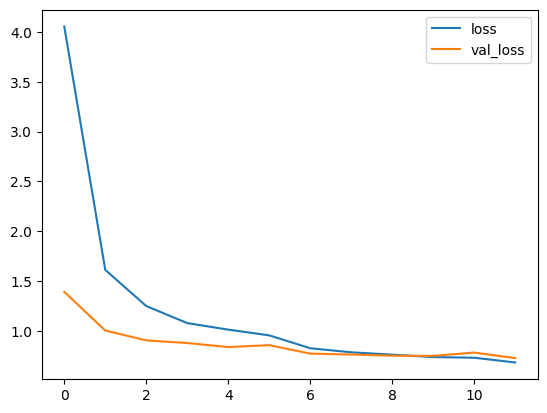

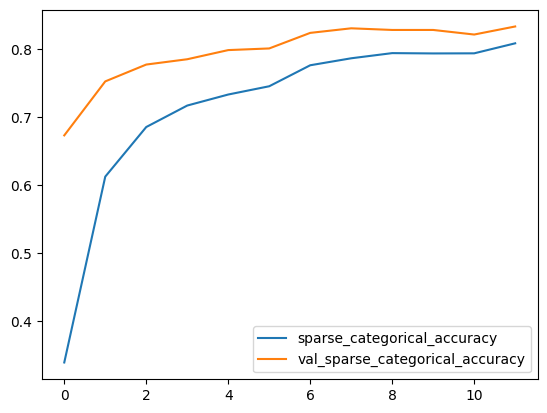

In [21]:
# Plot learning curves
history_frame = pd.DataFrame(history.history)
print(history_frame.columns) 

history_frame[['loss', 'val_loss']].plot()
history_frame[['sparse_categorical_accuracy', 'val_sparse_categorical_accuracy']].plot();

## Validation - Confusion Matrix and other metrics

232/232 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step
f1: 0.886, precision: 0.915, recall: 0.873


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


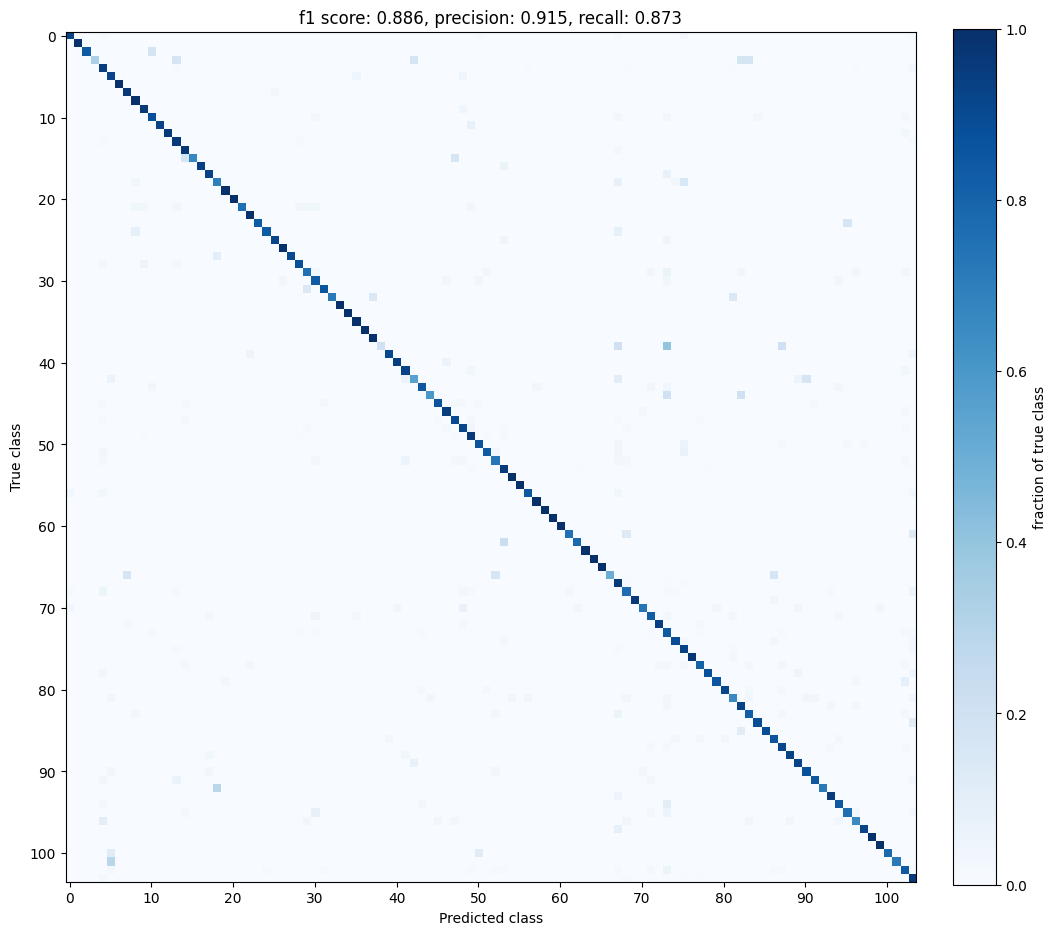

true 38 -> predicted 73: 40%
true 101 -> predicted 5: 29%
true 92 -> predicted 18: 29%
true 62 -> predicted 53: 22%
true 44 -> predicted 82: 20%
true 38 -> predicted 87: 20%
true 38 -> predicted 67: 20%
true 44 -> predicted 73: 20%
true 3 -> predicted 83: 17%
true 23 -> predicted 95: 17%


In [22]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

class_ids = list(range(num_classes))

# 1. True and predicted labels (validation set in fixed order)
cmdataset = get_validation_dataset(ordered=True)
images_ds = cmdataset.map(lambda image, label: image)
labels_ds = cmdataset.map(lambda image, label: label).unbatch()

cm_correct_labels = next(iter(labels_ds.batch(NUM_VALIDATION_IMAGES))).numpy()
cm_probabilities = model.predict(images_ds)
cm_predictions = np.argmax(cm_probabilities, axis=-1)

# 2. Macro-averaged metrics over all classes
score = f1_score(cm_correct_labels, cm_predictions,
                 labels=class_ids, average='macro', zero_division=0)
precision = precision_score(cm_correct_labels, cm_predictions,
                            labels=class_ids, average='macro', zero_division=0)
recall = recall_score(cm_correct_labels, cm_predictions,
                      labels=class_ids, average='macro', zero_division=0)
print(f"f1: {score:.3f}, precision: {precision:.3f}, recall: {recall:.3f}")

# 3. Confusion matrix, normalized by row (true class)
cmat = confusion_matrix(cm_correct_labels, cm_predictions, labels=class_ids)
row_sums = np.maximum(cmat.sum(axis=1, keepdims=True), 1)  # avoid division by zero
cmat = cmat / row_sums

# 4. Plot
def display_confusion_matrix(cmat, score, precision, recall):
    plt.figure(figsize=(12, 12))
    plt.imshow(cmat, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(fraction=0.046, pad=0.04, label='fraction of true class')
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.xticks(range(0, num_classes, 10))
    plt.yticks(range(0, num_classes, 10))
    plt.title(f"f1 score: {score:.3f}, precision: {precision:.3f}, recall: {recall:.3f}")
    #plt.savefig("output.png")
    plt.show()

display_confusion_matrix(cmat, score, precision, recall)

# 5. Most frequent confusions (off-diagonal entries)
off_diag = cmat.copy()
np.fill_diagonal(off_diag, 0)
top = np.dstack(np.unravel_index(np.argsort(off_diag.ravel())[::-1][:10], off_diag.shape))[0]

for true_c, pred_c in top:
    print(f"true {true_c} -> predicted {pred_c}: {off_diag[true_c, pred_c]:.0%}")

Precision (0.915) is higher than recall (0.873): when the model predicts a class it is usually right, but it misses some images of the harder classes.

The confusion matrix is strongly diagonal, and the errors are scattered rather than concentrated in a few systematic confusions.
The most frequent confusions are: 38→73 (40%), 101→5 (29%), 92→18 (29%), 62→53 (22%), 44→82 (20%), 38→87 and 38→67 (20%), 44→73 (20%), 3→83 (17%), 23→95 (17%).

## Test predictions - For submission

In [23]:
test_ds = get_test_dataset(ordered=True)

print('Computing predictions...')
test_images_ds = test_ds.map(lambda image, idnum: image)
probabilities = model.predict(test_images_ds)
predictions = np.argmax(probabilities, axis=-1)
print(predictions)

Computing predictions...
462/462 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[ 28 103  67 ...  95  62  45]


In [24]:
print('Generating submission.csv file...')

# Get image ids from test set and convert to integers
test_ids_ds = test_ds.map(lambda image, idnum: idnum).unbatch()
test_ids = next(iter(test_ids_ds.batch(NUM_TEST_IMAGES))).numpy().astype('U')

# Write the submission file
np.savetxt(
    'submission.csv',
    np.rec.fromarrays([test_ids, predictions]),
    fmt=['%s', '%d'],
    delimiter=',',
    header='id,label',
    comments='',
)

# Look at the first few predictions
!head submission.csv

Generating submission.csv file...
id,label
52a88af32,28
dfc9c6a23,103
f267d94cc,67
8a952300f,81
f1184530f,4
6e4cea791,4
8f76524a3,96
ff889e23b,12
6e08cae12,67
